<a href="https://colab.research.google.com/github/AlbertPuentes/Percepcion_Actvidad_Procesamiento_IMG./blob/main/ACT_Tratamiento_IMG_Percepcion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:

# CLASIFICACIÓN Y DETECCIÓN INDIVIDUAL DE MANZANAS ROJAS Y FRUTAS
# 1. INSTALACIÓN E IMPORTACIÓN DE DEPENDENCIAS

print("Cargando librerías...")
import os
import sys
import shutil
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import cv2

try:
    import tensorflow as tf
    from tensorflow.keras import layers, models
    from ultralytics import YOLO
except ImportError:
    print("Instalando TensorFlow y Ultralytics (YOLO)...")
    !pip install -q tensorflow ultralytics opencv-python
    import tensorflow as tf
    from tensorflow.keras import layers, models
    from ultralytics import YOLO

# Detectar si estamos en Google Colab
EN_COLAB = "google.colab" in sys.modules
if EN_COLAB:
    from google.colab import files
    from google.colab.patches import cv2_imshow
else:
    print("ADVERTENCIA: Este script está optimizado para Google Colab.")

# 2. CONFIGURACIÓN Y CREACIÓN DE CARPETAS TEMPORALES
BASE_DIR = "/content/dataset" if EN_COLAB else "./dataset"
TRAIN_DIR = os.path.join(BASE_DIR, "train")
VAL_DIR = os.path.join(BASE_DIR, "validation")
CLASES = ["manzanas_rojas", "otras_frutas"]

print("\nCreando estructura de carpetas temporales...")
for directorio in [TRAIN_DIR, VAL_DIR]:
    for clase in CLASES:
        os.makedirs(os.path.join(directorio, clase), exist_ok=True)

# 3. FUNCIÓN PARA ORGANIZAR ARCHIVOS SUBIDOS
def organizar_archivos(archivos_subidos, destino_dir):
    for nombre_archivo in archivos_subidos.keys():
        if nombre_archivo.endswith('.zip'):
            print(f"Descomprimiendo {nombre_archivo} en {destino_dir}...")
            with zipfile.ZipFile(nombre_archivo, 'r') as zip_ref:
                zip_ref.extractall(destino_dir)
            os.remove(nombre_archivo)
        else:
            nombre_final = os.path.basename(nombre_archivo)
            shutil.move(nombre_archivo, os.path.join(destino_dir, nombre_final))
    print(f"✓ Archivos organizados en: {destino_dir}\n")

# 4. CARGA DE IMÁGENES AL ENTORNO
if EN_COLAB:

    print("PASO 1: SUBIR IMÁGENES DE ENTRENAMIENTO (TRAIN.ZIP)")
    archivos_train = files.upload()
    if archivos_train:
        organizar_archivos(archivos_train, TRAIN_DIR)

    print("PASO 2: SUBIR IMÁGENES DE VALIDACIÓN (VAL.ZIP)")
    archivos_val = files.upload()
    if archivos_val:
        organizar_archivos(archivos_val, VAL_DIR)



Cargando librerías...

Creando estructura de carpetas temporales...
PASO 1: SUBIR IMÁGENES DE ENTRENAMIENTO (TRAIN.ZIP)


Saving Manzanas_Train.zip to Manzanas_Train.zip
Descomprimiendo Manzanas_Train.zip en /content/dataset/train...
✓ Archivos organizados en: /content/dataset/train

PASO 2: SUBIR IMÁGENES DE VALIDACIÓN (VAL.ZIP)


Saving Validacion.zip to Validacion.zip
Descomprimiendo Validacion.zip en /content/dataset/validation...
✓ Archivos organizados en: /content/dataset/validation




Preparando Datasets para el modelo...
Found 20 files belonging to 3 classes.
Found 20 files belonging to 3 classes.

Construyendo la arquitectura de la red neuronal...

INICIANDO ENTRENAMIENTO (CNN)...
Epoch 1/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.4000 - loss: 1.0986 - val_accuracy: 1.0000 - val_loss: 0.0034
Epoch 2/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 947ms/step - accuracy: 1.0000 - loss: 0.0119 - val_accuracy: 1.0000 - val_loss: 5.9404e-05
Epoch 3/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 490ms/step - accuracy: 1.0000 - loss: 3.5664e-04 - val_accuracy: 1.0000 - val_loss: 1.7881e-06
Epoch 4/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 584ms/step - accuracy: 1.0000 - loss: 7.5662e-05 - val_accuracy: 1.0000 - val_loss: 7.1526e-08
Epoch 5/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 474ms/step - accuracy: 1.0000 - loss: 1.3828e-06 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 6/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 608ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 7/

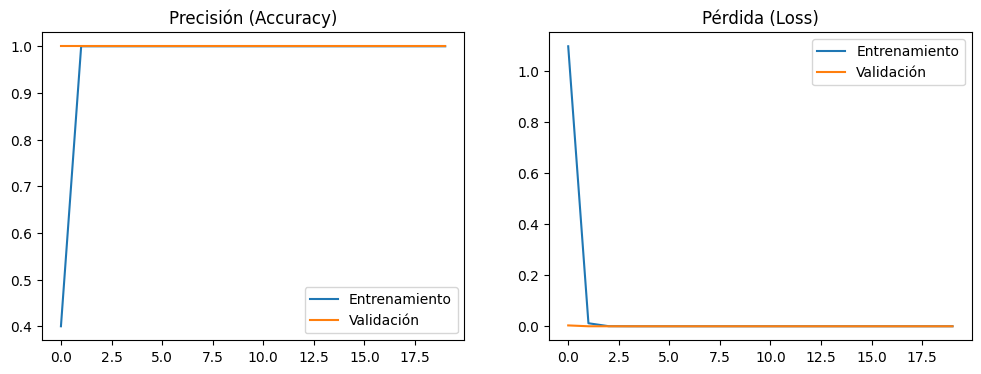

EVALUANDO INDIVIDUALMENTE OBJETOS EN IMÁGENES DE VALIDACIÓN

Analizando imagen: carros-todoterreno-ram-1000.jpg


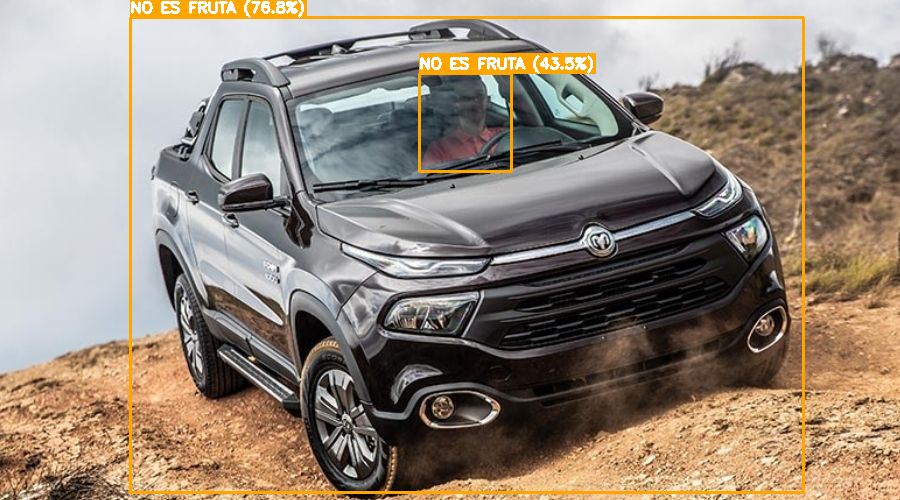


Analizando imagen: IMG9.jpg


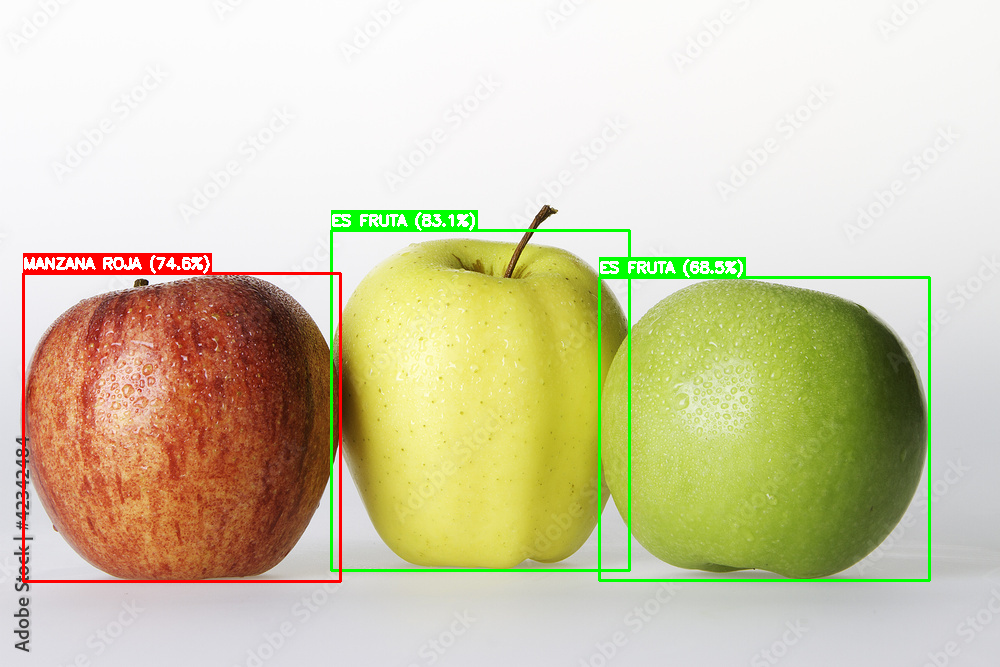


Analizando imagen: IMG4.jpg


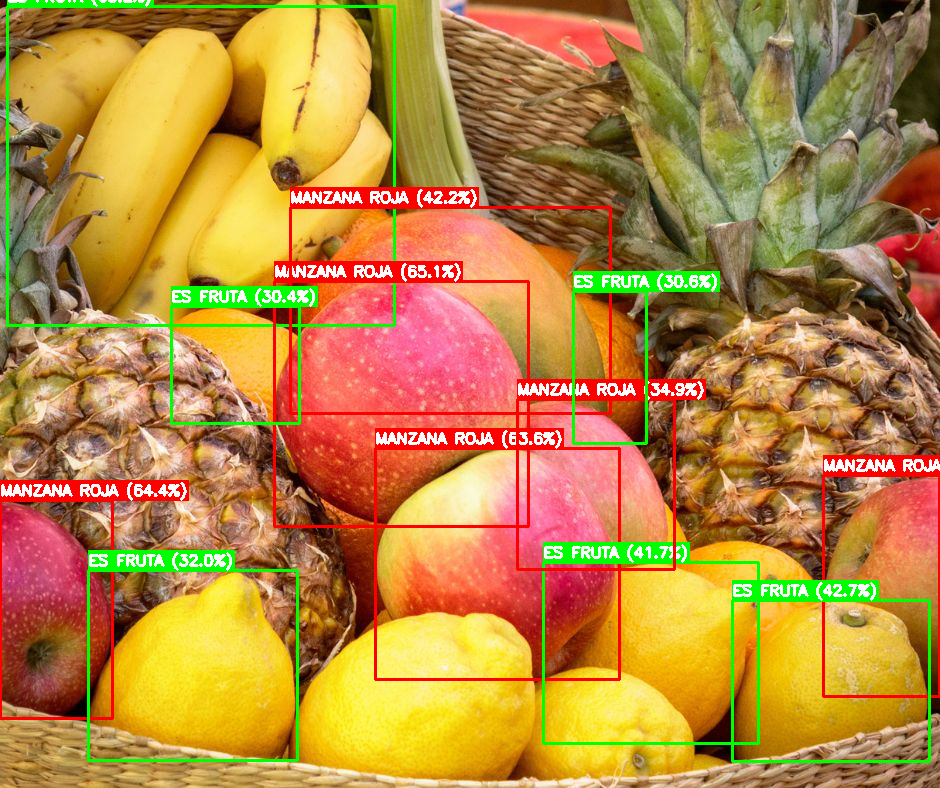


Analizando imagen: IMG18.jpg


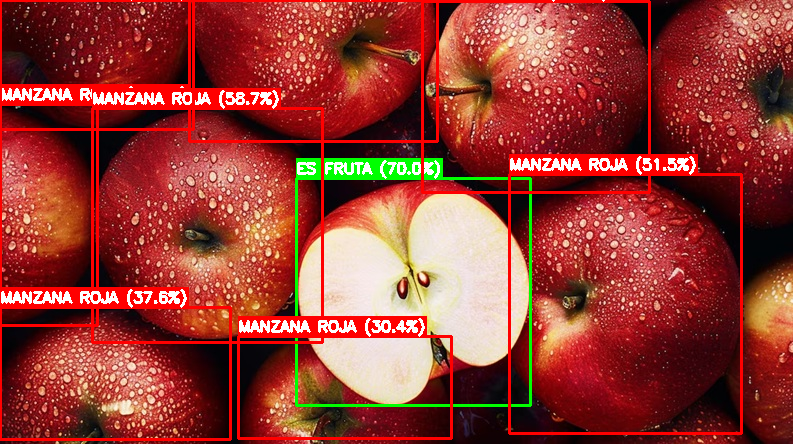


Analizando imagen: Grupo_de_personas.jpg


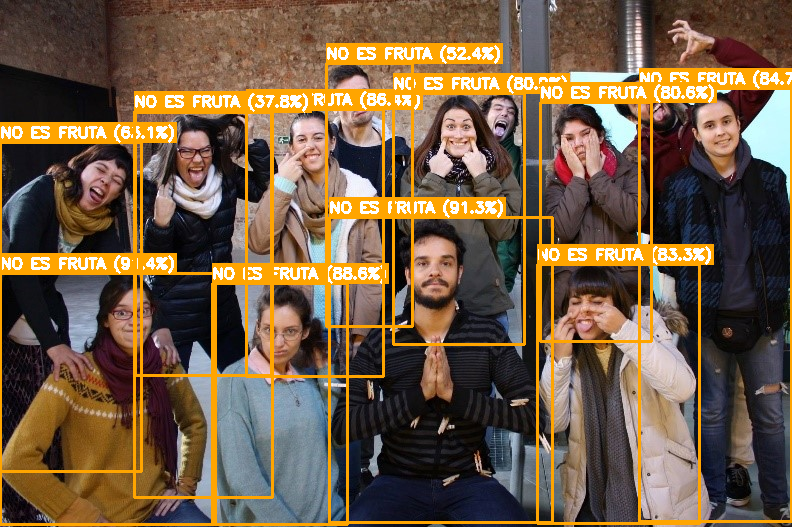

PROCESO FINALIZADO


In [21]:
# 5. PREPARACIÓN DE LOS DATASETS PARA TENSORFLOW
print("\nPreparando Datasets para el modelo...")
IMG_HEIGHT = 150
IMG_WIDTH = 150
BATCH_SIZE = 32

train_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR, shuffle=True, image_size=(IMG_HEIGHT, IMG_WIDTH), batch_size=BATCH_SIZE)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR, shuffle=True, image_size=(IMG_HEIGHT, IMG_WIDTH), batch_size=BATCH_SIZE)

class_names = train_dataset.class_names
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_dataset.cache().prefetch(buffer_size=AUTOTUNE)


# 6. CONSTRUCCIÓN DE LA RED NEURONAL CONVOLUCIONAL (CNN)
print("\nConstruyendo la arquitectura de la red neuronal...")
model = models.Sequential([
    layers.Rescaling(1./255, input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    layers.Conv2D(16, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(len(class_names), activation='softmax')
])

model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
              metrics=['accuracy'])


# 7. ENTRENAMIENTO DEL MODELO
print("\nINICIANDO ENTRENAMIENTO (CNN)...")
EPOCHS = 20
history = model.fit(train_dataset, validation_data=validation_dataset, epochs=EPOCHS)


# 8. VISUALIZACIÓN DE RENDIMIENTO GENERAL
acc, val_acc = history.history['accuracy'], history.history['val_accuracy']
loss, val_loss = history.history['loss'], history.history['val_loss']

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(range(EPOCHS), acc, label='Entrenamiento')
plt.plot(range(EPOCHS), val_acc, label='Validación')
plt.legend(loc='lower right')
plt.title('Precisión (Accuracy)')

plt.subplot(1, 2, 2)
plt.plot(range(EPOCHS), loss, label='Entrenamiento')
plt.plot(range(EPOCHS), val_loss, label='Validación')
plt.legend(loc='upper right')
plt.title('Pérdida (Loss)')
plt.show()

# 9. FUNCIONES AUXILIARES PARA DETECCIÓN DE COLOR (ROJO)

def es_color_rojo(imagen_recorte):
    if imagen_recorte.size == 0: return False
    hsv = cv2.cvtColor(imagen_recorte, cv2.COLOR_BGR2HSV)
    mask = cv2.inRange(hsv, np.array([0, 50, 50]), np.array([10, 255, 255])) + \
           cv2.inRange(hsv, np.array([170, 50, 50]), np.array([180, 255, 255]))
    proporcion_roja = cv2.countNonZero(mask) / (imagen_recorte.shape[0] * imagen_recorte.shape[1] + 1e-6)
    return proporcion_roja > 0.20

# 10. DETECCIÓN INDIVIDUAL DE FRUTAS VS NO FRUTAS EN VALIDACIÓN (YOLO)
print("EVALUANDO INDIVIDUALMENTE OBJETOS EN IMÁGENES DE VALIDACIÓN")

# Cargamos el modelo YOLO que es experto en detectar siluetas y formas
yolo_model = YOLO("yolov8n.pt")

# Clases en COCO que consideramos "Frutas" por su forma
CLASES_FRUTAS_COCO = [46, 47, 49] # 46: banana, 47: apple, 49: orange

# Tomamos algunas imágenes de la carpeta de validación
imagenes_val_rutas = []
for root, dirs, files in os.walk(VAL_DIR):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            imagenes_val_rutas.append(os.path.join(root, file))

# Procesamos un máximo de 5 imágenes para no saturar la pantalla
for ruta_img in imagenes_val_rutas[:5]:
    img_cv2 = cv2.imread(ruta_img)
    if img_cv2 is None: continue

    resultados_yolo = yolo_model(img_cv2, verbose=False)

    for r in resultados_yolo:
        if r.boxes is None: continue

        for box in r.boxes:
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            cls_id = int(box.cls[0].item())
            similitud = float(box.conf[0].item()) * 100 # Porcentaje de confianza

            # Filtramos predicciones muy dudosas
            if similitud < 30.0: continue

            recorte = img_cv2[y1:y2, x1:x2]

            # Lógica de decisión: Forma (YOLO) + Color (OpenCV)
            if cls_id in CLASES_FRUTAS_COCO:
                if cls_id == 47 and es_color_rojo(recorte):
                    etiqueta = f"MANZANA ROJA ({similitud:.1f}%)"
                    color_caja = (0, 0, 255) # Rojo en BGR
                else:
                    etiqueta = f"ES FRUTA ({similitud:.1f}%)"
                    color_caja = (0, 255, 0) # Verde en BGR
            else:
                etiqueta = f"NO ES FRUTA ({similitud:.1f}%)"
                color_caja = (0, 165, 255) # Naranja para no-frutas (ej. personas, tazas)

            # Dibujar el cuadro y la etiqueta en la imagen
            cv2.rectangle(img_cv2, (x1, y1), (x2, y2), color_caja, 2)

            # Fondo para el texto para que sea legible
            (w, h), _ = cv2.getTextSize(etiqueta, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 2)
            cv2.rectangle(img_cv2, (x1, y1 - 20), (x1 + w, y1), color_caja, -1)
            cv2.putText(img_cv2, etiqueta, (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 2)

    # Mostrar la imagen procesada
    if EN_COLAB:
        print(f"\nAnalizando imagen: {os.path.basename(ruta_img)}")
        cv2_imshow(img_cv2)

print("PROCESO FINALIZADO")